# Data Storytelling Project Notebook

Brandon Kung 

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# Loading in the Subnational HDI Dataset and Exploration 

In [5]:
shdi_df = pd.read_csv('../data/GDL-Subnational-HDI-data.csv')

In [6]:
shdi_df.head()

,Country,Continent,ISO_Code,Level,GDLCODE,Region,1990,1991,1992,1993,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Cambodia,Asia/Pacific,KHM,National,KHMt,Total,0.387,0.392,0.396,0.399,...,0.557,0.562,0.570,0.578,0.586,0.593,0.595,0.594,0.602,0.606
1,Cambodia,Asia/Pacific,KHM,Subnat,KHMr101,Banteay Mean Chey,0.372,0.377,0.380,0.383,...,0.564,0.573,0.586,0.598,0.610,0.621,0.626,0.630,0.638,0.642
2,Cambodia,Asia/Pacific,KHM,Subnat,KHMr113,Bat Dambang-Krong Pailin,0.396,0.401,0.405,0.407,...,0.581,0.582,0.586,0.590,0.593,0.596,0.594,0.589,0.596,0.600
3,Cambodia,Asia/Pacific,KHM,Subnat,KHMr102,Kampong Cham (incl Tboung Khmum),0.372,0.376,0.380,0.382,...,0.535,0.536,0.540,0.543,0.546,0.548,0.545,0.540,0.547,0.551
4,Cambodia,Asia/Pacific,KHM,Subnat,KHMr103,Kampong Chhnang,0.351,0.355,0.359,0.361,...,0.541,0.551,0.563,0.576,0.588,0.599,0.605,0.609,0.617,0.621


In [7]:
shdi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 40 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    43 non-null     object 
 1   Continent  43 non-null     object 
 2   ISO_Code   43 non-null     object 
 3   Level      43 non-null     object 
 4   GDLCODE    43 non-null     object 
 5   Region     43 non-null     object 
 6   1990       43 non-null     float64
 7   1991       43 non-null     float64
 8   1992       43 non-null     float64
 9   1993       43 non-null     float64
 10  1994       43 non-null     float64
 11  1995       43 non-null     float64
 12  1996       43 non-null     float64
 13  1997       43 non-null     float64
 14  1998       43 non-null     float64
 15  1999       43 non-null     float64
 16  2000       43 non-null     float64
 17  2001       43 non-null     float64
 18  2002       43 non-null     float64
 19  2003       43 non-null     float64
 20  2004       4

The Lao data has more subnational units and it was bombed more, so we will focus on Lao.

In [5]:
# filtering dataset to include only Lao
lao_shdi = shdi_df[(shdi_df['ISO_Code'] == 'LAO')]

In [7]:
print(lao_shdi.columns)

Index(['Country', 'Continent', 'ISO_Code', 'Level', 'GDLCODE', 'Region',
       '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016',
       '2017', '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype='object')


In [8]:
id_cols = ['Country', 'Continent', 'ISO_Code', 'Level', 'GDLCODE', 'Region']

lao_shdi_df = pd.melt(
    lao_shdi,
    id_vars=id_cols,
    var_name='year',
    value_name='shdi_value'  
)

In [9]:
print(lao_shdi_df.columns)

Index(['Country', 'Continent', 'ISO_Code', 'Level', 'GDLCODE', 'Region',
       'year', 'shdi_value'],
      dtype='object')


In [11]:
lao_shdi_df.head()

,Country,Continent,ISO_Code,Level,GDLCODE,Region,year,shdi_value
0,Lao,Asia/Pacific,LAO,National,LAOt,Total,1990,0.409
1,Lao,Asia/Pacific,LAO,Subnat,LAOr117,Attapeu,1990,0.379
2,Lao,Asia/Pacific,LAO,Subnat,LAOr105,Bokeo,1990,0.380
3,Lao,Asia/Pacific,LAO,Subnat,LAOr111,Borikhamxay,1990,0.453
4,Lao,Asia/Pacific,LAO,Subnat,LAOr116,Champasack,1990,0.410


Text(0, 0.5, 'Subnational HDI Score')

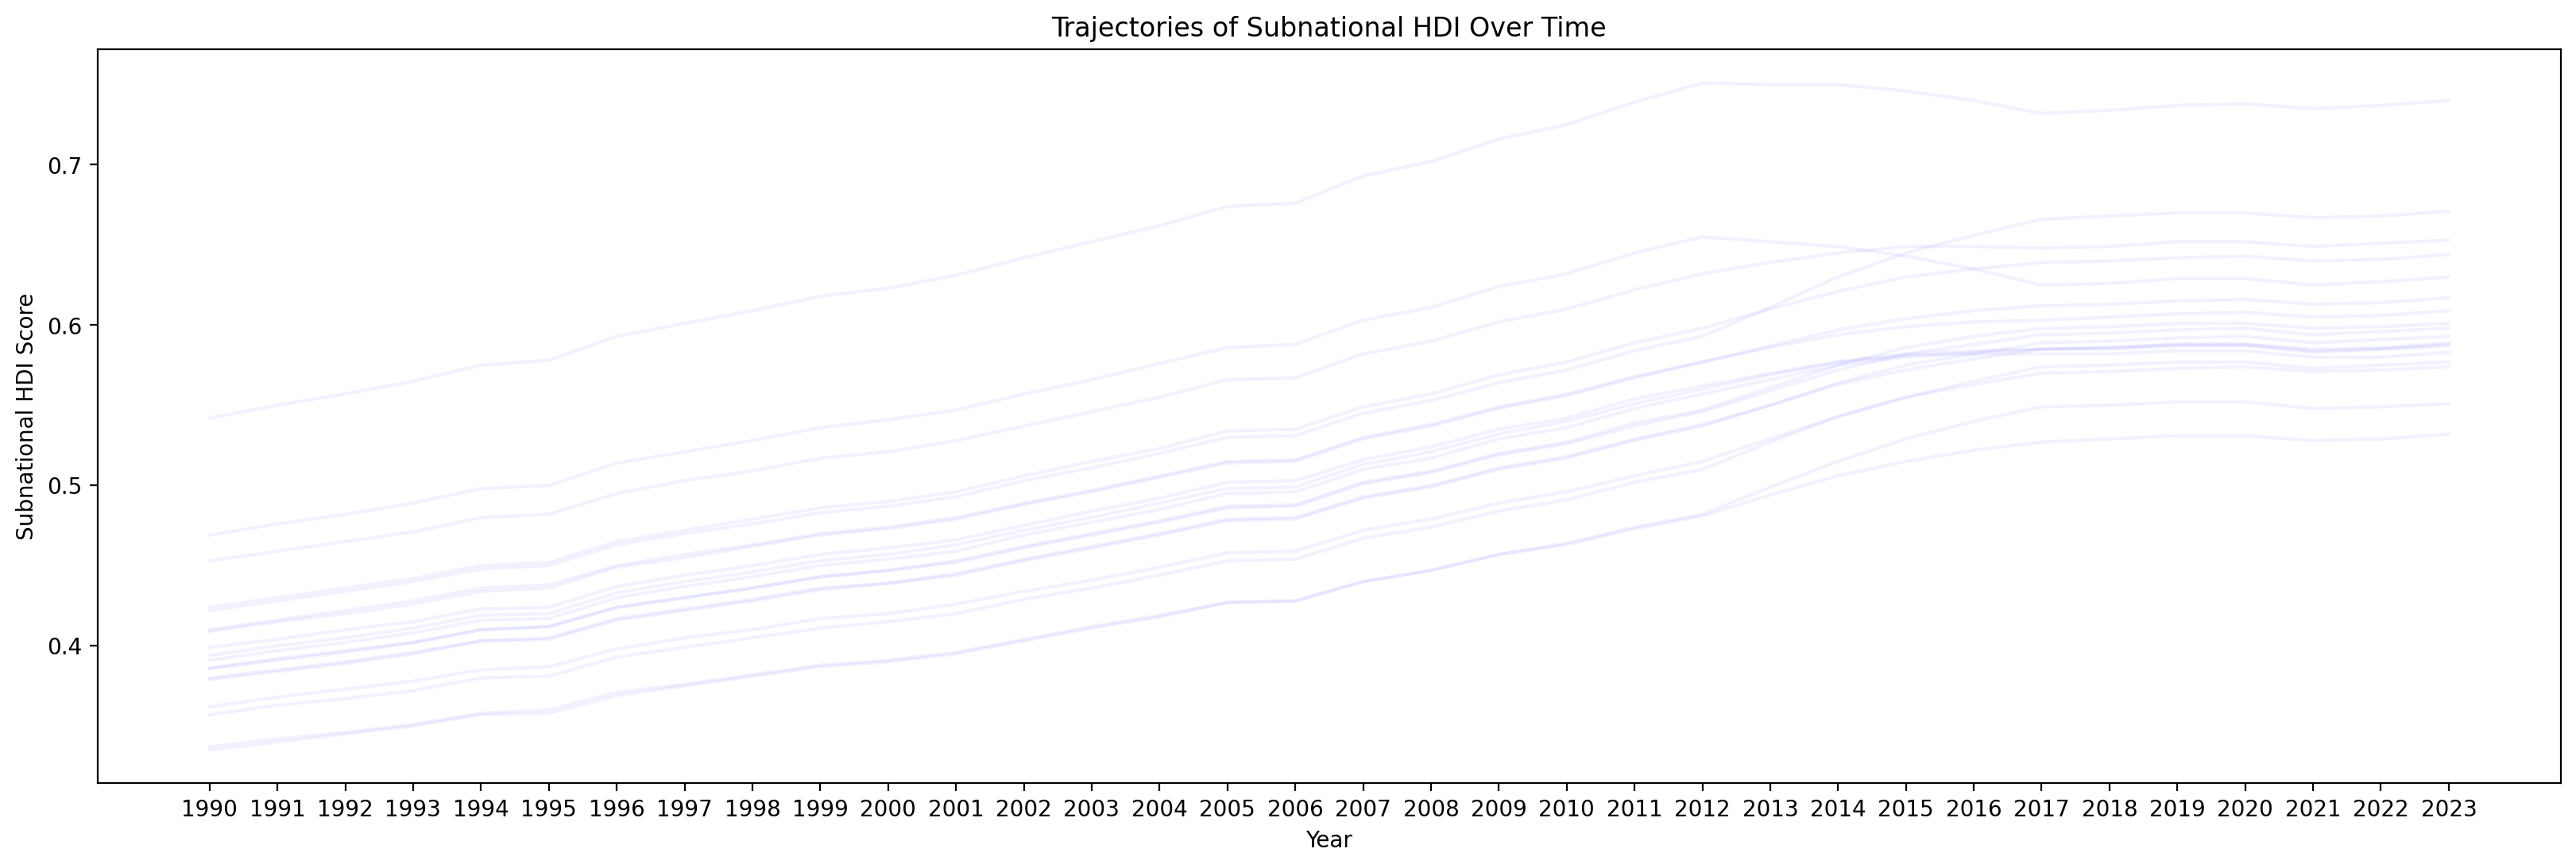

In [15]:
# Graphing line trend for exploration purposes
plt.figure(figsize=(20, 6))

for key, grp in lao_shdi_df.groupby(['GDLCODE']):
    plt.plot(grp['year'], grp['shdi_value'], alpha=0.05, color='blue')

plt.title('Trajectories of Subnational HDI Over Time')
plt.xlabel('Year')
plt.ylabel('Subnational HDI Score')

In [2]:
import polars as pl

In [4]:
# using polars to filter the data because it's very large 
columns_to_keep = [
    'TGTCOUNTRY',
    'TGTLATDD_DDD_WGS84',
    'TGTLONDDD_DDD_WGS84',
    'MSNDATE',
    'WEAPONTYPEWEIGHT',
    'NUMWEAPONSDELIVERED',
    'MFUNC_DESC_CLASS',
    'WEAPONTYPECLASS',
    'WEAPONTYPE'
]

(
    pl.scan_csv('../data/large_thor_file.csv', ignore_errors=True)
    .select(columns_to_keep)
    .filter(pl.col('TGTCOUNTRY').str.to_uppercase() == 'LAOS')
    .collect()
    .write_csv('laos_bombing_clean.csv')
)

In [5]:
laos_df = pd.read_csv('laos_bombing_clean.csv')

In [6]:
laos_df.head()

,TGTCOUNTRY,TGTLATDD_DDD_WGS84,TGTLONDDD_DDD_WGS84,MSNDATE,WEAPONTYPEWEIGHT,NUMWEAPONSDELIVERED,MFUNC_DESC_CLASS,WEAPONTYPECLASS,WEAPONTYPE
0,LAOS,NaN,NaN,1973-07-28,0,0,NONKINETIC,NaN,NaN
1,LAOS,16.902500,106.014166,1970-02-02,750,2,KINETIC,NaN,BLU27 FIRE BOMB (750)
2,LAOS,19.602222,103.597222,1970-11-25,500,6,KINETIC,NaN,MK 82 GP BOMB (500) LD
3,LAOS,14.573611,106.689722,1972-03-08,0,0,KINETIC,NaN,NaN
4,LAOS,NaN,NaN,1971-12-27,0,0,NONKINETIC,NaN,NaN
